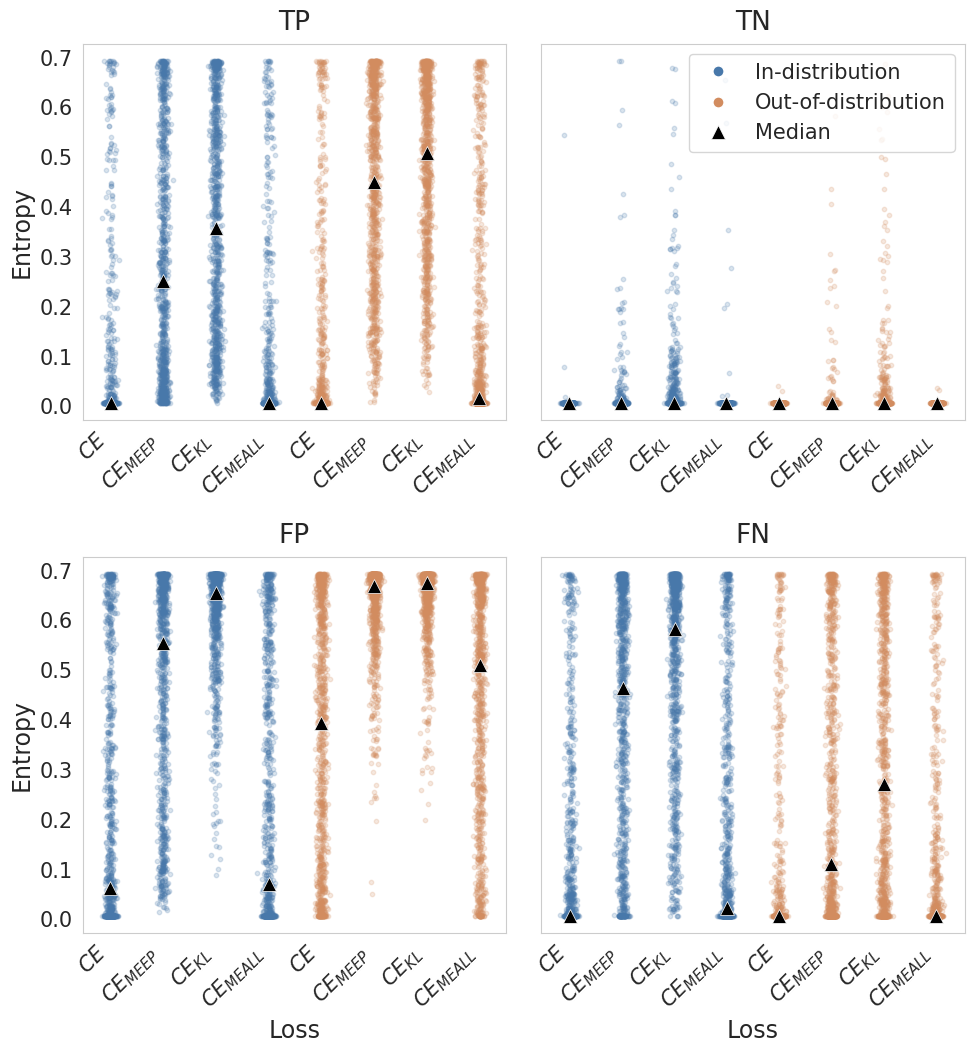

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import nibabel as nib # Explicitly import nibabel

# Ensure Matplotlib uses its internal mathtext engine, not an external LaTeX installation
plt.rcParams['text.usetex'] = False

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule
from notebooks.utils.metrics_utils import * # Assumed to import entropy, get_gt_paths, get_b_mask_path

sns.set_style("white")

from scipy.stats import pearsonr, spearmanr

# Font sizes
SMALL_SIZE = 15  # Increased from 13
MEDIUM_SIZE = 17 # Increased from 15
BIGGER_SIZE = 19 # Increased from 17

# Apply global font settings
plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

# Data paths and configurations
data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2], seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

for key, val in group_test.items():
    test_splits[key] = []
    for center_val in val:
        test_splits[key] += test_splits[center_val]
        del test_splits[center_val]
        centers_test.remove(center_val)
    centers_test.append(key)

plot_data_global = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': centers_test,
    'test_splits': test_splits,
    'losses': losses,
}

def uncertainty_confusion(plot_data_func_arg, n_samples=1000):
    centers_train_f, runs_to_compare_f, centers_test_f, test_splits_f, losses_f = plot_data_func_arg.values()

    # Define colors to match fig4.png
    color_in_distribution = '#4878AA'  # Muted blue
    color_out_of_distribution = '#D28C5F' # Muted orange/brown

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }
    
    subject_level_entropy_data = {} 
    median_entropy_data = {} 

    for tr_center in centers_train_f:
        for loss_type in losses_f:
            subject_level_entropy_data[loss_type] = {}
            median_entropy_data[loss_type] = {}
            
            run_id_key = f'{loss_type} {tr_center}'
            if run_id_key not in runs_to_compare_f:
                print(f'No run for {run_id_key}. Skipping.')
                continue
            run_name = runs_to_compare_f[run_id_key]

            for ts_center in centers_test_f:
                subject_level_entropy_data[loss_type][ts_center] = {
                    "TP": np.array([]), "FP": np.array([]),
                    "TN": np.array([]), "FN": np.array([])
                }
                median_entropy_data[loss_type][ts_center] = {}
                
                gt_pths = get_gt_paths(test_splits_f[ts_center])
                for subj_dir_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_dir_path, f'pred_wmh_softmax_{run_name}.nii.gz')
                    gt_path = os.path.join(subj_dir_path, f'gt_wmh_{run_name}.nii.gz')
                    
                    if not (os.path.exists(pred_softmax_path) and os.path.exists(gt_path)):
                        # print(f"Warning: Missing prediction or GT file for {subj_dir_path} with run {run_name}. Skipping subject.")
                        continue

                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    gt = nib.load(gt_path).get_fdata()
                    
                    brain_mask_path = get_b_mask_path(subj_dir_path)
                    if not os.path.exists(brain_mask_path):
                        # print(f"Warning: Missing brain mask for {subj_dir_path}. Skipping subject.")
                        continue
                    b_mask = nib.load(brain_mask_path).get_fdata()

                    gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]
                    neg_sftmx = pred_softmax[:, :, :, 0].flatten()
                    pos_sftmx = pred_softmax[:, :, :, 1].flatten()
                    neg_gt = gt_one_hot[:, :, :, 0].flatten()
                    pos_gt = gt_one_hot[:, :, :, 1].flatten()
                    b_mask_flat = b_mask.flatten()

                    thres_brain = np.where(b_mask_flat == 1)[0]
                    pos_brain = pos_sftmx[thres_brain]
                    neg_brain = neg_sftmx[thres_brain]
                    pos_gt_brain = pos_gt[thres_brain]
                    neg_gt_brain = neg_gt[thres_brain]

                    tp_indices = np.where((pos_brain >= 0.5) & (pos_gt_brain == 1))[0]
                    tp_unc = entropy(pos_brain[tp_indices], apply_mean=False)
                    subject_level_entropy_data[loss_type][ts_center]["TP"] = np.append(subject_level_entropy_data[loss_type][ts_center]["TP"], tp_unc)

                    fp_indices = np.where((pos_brain >= 0.5) & (pos_gt_brain == 0))[0]
                    fp_unc = entropy(pos_brain[fp_indices], apply_mean=False)
                    subject_level_entropy_data[loss_type][ts_center]["FP"] = np.append(subject_level_entropy_data[loss_type][ts_center]["FP"], fp_unc)

                    tn_indices = np.where((neg_brain >= 0.5) & (neg_gt_brain == 1))[0]
                    tn_unc = entropy(neg_brain[tn_indices], apply_mean=False)
                    subject_level_entropy_data[loss_type][ts_center]["TN"] = np.append(subject_level_entropy_data[loss_type][ts_center]["TN"], tn_unc)

                    fn_indices = np.where((neg_brain >= 0.5) & (neg_gt_brain == 0))[0]
                    fn_unc = entropy(neg_brain[fn_indices], apply_mean=False)
                    subject_level_entropy_data[loss_type][ts_center]["FN"] = np.append(subject_level_entropy_data[loss_type][ts_center]["FN"], fn_unc)
                
                if n_samples:
                    for category_key in subject_level_entropy_data[loss_type][ts_center].keys():
                        current_values = subject_level_entropy_data[loss_type][ts_center][category_key]
                        if len(current_values) > n_samples:
                            subject_level_entropy_data[loss_type][ts_center][category_key] = np.random.choice(
                                current_values, n_samples, replace=False)
                
                for category_key in ["TP", "TN", "FP", "FN"]:
                    values_for_median = subject_level_entropy_data[loss_type][ts_center][category_key]
                    if len(values_for_median) > 0:
                         median_entropy_data[loss_type][ts_center][category_key] = np.median(values_for_median)
                    else:
                         median_entropy_data[loss_type][ts_center][category_key] = np.nan

    fig, axes = plt.subplots(2, 2, figsize=(10, 11), sharey=True)
    axes = axes.flatten()
    confusion_categories = ["TP", "TN", "FP", "FN"]
    plot_loss_order = [l for l in losses_f if l in subject_level_entropy_data]

    for i, plot_category in enumerate(confusion_categories):
        all_plot_points = []
        for distribution_type in ["In-distribution", "Out-of-distribution"]:
            for loss_val in plot_loss_order:
                if loss_val not in subject_level_entropy_data: continue
                for center_name, metrics_data in subject_level_entropy_data[loss_val].items():
                    renamed_center = test_center_rename.get(center_name, center_name)
                    if renamed_center == distribution_type:
                        all_plot_points.extend(
                            [(plot_category, loss_val, distribution_type, val) for val in metrics_data[plot_category]]
                        )
        
        df_plot = pd.DataFrame(all_plot_points, columns=['Metric', 'Loss', 'Distribution', 'Value'])
        x_positions = np.arange(len(plot_loss_order) * 2)

        for j, dist_type in enumerate(['In-distribution', 'Out-of-distribution']):
            df_dist_subset = df_plot[df_plot['Distribution'] == dist_type]
            # Use new colors
            point_color = color_in_distribution if dist_type == 'In-distribution' else color_out_of_distribution
            for k, loss_k_val in enumerate(plot_loss_order):
                group_data = df_dist_subset[df_dist_subset['Loss'] == loss_k_val]
                x_coord = x_positions[k + j * len(plot_loss_order)]
                y_coords = group_data['Value']
                if len(y_coords) > 0:
                    axes[i].scatter(x_coord + np.random.normal(0, 0.05, len(y_coords)), y_coords,
                                    color=point_color, alpha=0.2, s=10) # scatter point alpha and size

        median_plot_points = []
        for loss_m_val, centers_m_data in median_entropy_data.items():
            if loss_m_val not in plot_loss_order: continue 
            for center_m_name, metrics_m_data in centers_m_data.items():
                if plot_category in metrics_m_data:
                    median_plot_points.append(
                        (plot_category, loss_m_val, test_center_rename.get(center_m_name, center_m_name), metrics_m_data[plot_category])
                    )
        df_median = pd.DataFrame(median_plot_points, columns=['Metric', 'Loss', 'Distribution', 'Value'])

        for j, dist_type in enumerate(['In-distribution', 'Out-of-distribution']):
            df_dist_median_subset = df_median[df_median['Distribution'] == dist_type]
            for k, loss_k_med_val in enumerate(plot_loss_order):
                group_median_data = df_dist_median_subset[df_dist_median_subset['Loss'] == loss_k_med_val]
                if not group_median_data.empty and not pd.isna(group_median_data['Value'].values[0]):
                    x_coord = x_positions[k + j * len(plot_loss_order)]
                    y_median = group_median_data['Value'].values[0]
                    axes[i].scatter(x_coord, y_median,
                                    marker='^', color='black',
                                    edgecolors='white', linewidths=0.5,
                                    s=100, zorder=3) # Median marker size increased to 100

        axes[i].set_title(f'{plot_category}', fontsize=BIGGER_SIZE, pad=10) # Changed from 16 to BIGGER_SIZE
        
        if i >= 2:
            axes[i].set_xlabel('Loss', fontsize=MEDIUM_SIZE) # Changed from BIGGER_SIZE to MEDIUM_SIZE
        if i % 2 == 0:
            axes[i].set_ylabel('Entropy', fontsize=MEDIUM_SIZE) # Changed from BIGGER_SIZE to MEDIUM_SIZE
            
        axes[i].tick_params(axis='both', which='major', labelsize=SMALL_SIZE) # Changed from MEDIUM_SIZE to SMALL_SIZE
        axes[i].set_xticks(x_positions)
        
        x_tick_labels_raw = plot_loss_order * 2
        x_tick_labels_latex = []
        for label in x_tick_labels_raw:
            if "_" in label:
                parts = label.split("_", 1)
                latex_label = fr"${parts[0]}_{{{parts[1]}}}$" 
            else:
                latex_label = fr"${label}$"
            x_tick_labels_latex.append(latex_label)
        axes[i].set_xticklabels(x_tick_labels_latex, rotation=45, ha='right')
        
        axes[i].grid(False)

    # Updated legend elements for colors and style
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', linestyle='None', 
               markerfacecolor=color_in_distribution, markersize=8, label='In-distribution'),
        Line2D([0], [0], marker='o', color='w', linestyle='None',
               markerfacecolor=color_out_of_distribution, markersize=8, label='Out-of-distribution'),
        Line2D([0], [0], marker='^', color='w', # Median marker in legend
               markerfacecolor='black', markeredgecolor='white', 
               markeredgewidth=0.5, markersize=10, label='Median') # markersize for legend median symbol
    ]

    axes[1].legend(handles=legend_elements, loc='upper right', fontsize=SMALL_SIZE)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    output_dir = 'notebooks/main/figs/pdfs/'
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, 'Figure4.pdf')
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.show()

uncertainty_confusion(plot_data_global, n_samples=1000)
